# Project Goal: Spotting Stroke Risk Factors Early

## 1. The Problem
Strokes are dangerous and life-threatening, but many of the things that cause them—like high blood pressure, high blood sugar, weight issues, and smoking—can be managed if caught early enough. Right now, doctors and hospitals need a better, faster way to look at a patient's everyday profile and figure out if they are at a high risk of having a stroke.

## 2. Our Goal
We want to look at the dataset **"healthcare-dataset-stroke-data.csv"** to see exactly which health and lifestyle habits are the biggest warning signs for a stroke. This will help us build a smart system in the future that can warn a patient before a stroke ever happens.

## 3. What We Need to Figure Out in Our Data Analysis (EDA)
Before we can build any smart tools, we need to answer three simple questions using our charts and data:
* **Which health factors matter most?** Does a person's age, weight (`bmi`), blood sugar level, or smoking habits change their chances of having a stroke?
* **How do we fix missing information?** Some patients are missing weight data (201 rows), and others have an "Unknown" smoking status. We need to decide the best way to clean this up without ruining our data.
* **How do we handle the unbalanced data?** Out of all 5,110 patients, only 249 actually had a stroke (less than 5%). Because the "No Stroke" group is so much bigger, we need to make sure our analysis doesn't completely ignore the small group of people who actually suffered a stroke.


# Literature Review: Key Studies for Exploratory Data Analysis (EDA)

The following two peer-reviewed academic papers provide the best direct blueprints for your **Exploratory Data Analysis (EDA)** phase on the stroke dataset. They focus heavily on feature importance, data profiling, handling missing values, and addressing class imbalances.

| Source & Author(s) | Focus of the Study | Data Profiling & Cleaning Insights (EDA Blueprint) | Key Findings for Visualizations |
| :--- | :--- | :--- | :--- |
| **Sutcu (2025)**<br>*PubMed Central (PMC)* | Feature Distribution & Risk Stratification | • Performed detailed statistical stratification across the 5,110 patient records.<br>• Focused on how continuous biological traits (`bmi`, `avg_glucose_level`) shift across age brackets. | • **Continuous Features matter most:** Ranked average blood glucose levels, BMI, and age as the most critical continuous variables to plot.<br>• **The Age Threshold:** Proved a non-linear risk surge, showing that stroke probability spikes dramatically **after age 60**. |
| **Jing (2022)**<br>*arXiv Repository* | Handling Missing Data & Class Imbalance | • Evaluated the danger of using a simple global mean to fill missing `bmi` entries, noting it falsely shrinks data variance.<br>• Addressed the heavy data skew, where only **4.87%** of patients had a stroke. | • **Imbalance Strategy:** Highlights that standard visual correlation plots can completely overlook the stroke group because it is so small.<br>• **Comorbidity Patterns:** Shows that analyzing overlapping conditions (like having *both* high blood pressure and heart disease) is more informative than analyzing them in isolation. |

---

### How to Apply These Two Papers to Your Code:
1. **From Sutcu (2025):** Create a scatter plot of `age` vs. `avg_glucose_level` and add a vertical line at **Age 60** to visually test if stroke occurrences cluster heavily to the right of that threshold.
2. **From Jing (2022):** Instead of using a basic `.fillna(df['bmi'].mean())`, group your data by `gender` and `age_bins` first, then fill the missing BMI values based on those specific subgroups to preserve realistic data variance.

In [3]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df=pd.read_csv(r"D:\practice files\healthcare-dataset-stroke-data.csv")

In [5]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


# hypothesis:
1. **Hypothesis 1:** Older patients with high blood pressure and high blood sugar levels have a much higher risk of having a stroke.
2. **Hypothesis 2:** Patients who currently smoke or used to smoke have higher stroke rates than patients who have never smoked.
3. **Hypothesis 3:** Patients with an unhealthy body weight (high BMI) are more likely to experience a stroke.

# Column Meanings Explained Simply

Here is a breakdown of what every single column in our dataset means, explained in plain English without confusing medical or data jargon:

### 1. `id`
* **What it means:** A unique identification number given to each patient. 
* **In easy words:** Think of it like a roll number in school or an employee ID. It doesn’t tell us anything about the patient's health; its only job is to make sure we don't mix up two different people.

### 2. `gender`
* **What it means:** The biological sex of the patient.
* **In easy words:** It shows whether the patient is recorded as **Male**, **Female**, or **Other**. In our data analysis, we will use this to see if men or women are more prone to strokes.

### 3. `age`
* **What it means:** How old the patient is in years.
* **In easy words:** For adults, it is a whole number (like 67 or 80). For tiny babies, it is shown as a decimal number (like 0.72 or 1.08). Age is highly important because our blood vessels naturally get weaker as we grow older.

### 4. `hypertension`
* **What it means:** Whether the patient has chronic high blood pressure.
* **In easy words:** High blood pressure damages blood vessels over time, making it easier for blockages to form. 
  * `1` = Yes, they have high blood pressure.
  * `0` = No, their blood pressure is normal.

### 5. `heart_disease`
* **What it means:** Whether the patient has an existing heart condition.
* **In easy words:** If someone's heart is already struggling to pump blood properly, it can easily lead to blood flow problems in the brain.
  * `1` = Yes, they have a heart disease.
  * `0` = No, their heart is healthy.

### 6. `ever_married`
* **What it means:** The marriage history of the patient.
* **In easy words:** It simply answers: *"Has this person ever been married?"* It will say **Yes** or **No**. In data science, we look at this to see if social or lifestyle factors link to health changes.

### 7. `work_type`
* **What it means:** The type of job the patient does.
* **In easy words:** Different jobs bring different levels of daily stress and physical movement. The choices in our data are:
  * **Private:** Working for a private company.
  * **Self-employed:** Running their own business.
  * **Govt_job:** Working a government job.
  * **children:** Kids who don't work.
  * **Never_worked:** Adults who have never had a job.

### 8. `Residence_type`
* **What it means:** The type of area where the patient lives.
* **In easy words:** It categorizes their living environment into two choices:
  * **Urban:** Living in a busy city (which might mean more fast-paced stress, but closer hospitals).
  * **Rural:** Living in the countryside or a village (which might mean a calmer environment but fewer big hospitals nearby).

### 9. `avg_glucose_level`
* **What it means:** The average amount of sugar found in the patient's blood.
* **In easy words:** Blood sugar comes from the food we eat and gives us energy. However, if your average sugar level is too high, it is a sign of diabetes. High blood sugar damages blood vessels and increases the risk of a stroke. 

### 10. `bmi` (Body Mass Index)
* **What it means:** A measurement that uses a person's height and weight to see if their weight is healthy.
* **In easy words:** It tells us if a person is underweight, normal weight, overweight, or obese. 
  * A normal BMI is usually between 18.5 and 24.9.
  * A high BMI (30 or above) means a person is carrying a lot of extra body weight, which can strain the heart and blood vessels.
  * *Note:* You have 201 missing values here (written as `NaN` or `N/A`), which we will need to handle during cleaning!

### 11. `smoking_status`
* **What it means:** The patient's history with smoking tobacco.
* **In easy words:** Smoking introduces harmful chemicals into the blood that narrow the arteries. The column has four values:
  * **smokes:** They currently smoke.
  * **formerly smoked:** They used to smoke but quit.
  * **never smoked:** They have never smoked.
  * **Unknown:** The data is missing because the patient didn't say.

### 12. `stroke` (Our Target Variable)
* **What it means:** Whether the patient actually suffered a stroke or not.
* **In easy words:** This is the most important column in our dataset—the one we are trying to predict.
  * `1` = Yes, the patient had a stroke.
  * `0` = No, the patient did not have a stroke.

In [8]:
# understanding the dataset size

df.shape

(5110, 12)

In [9]:
# identifying the numerical and categorical column:

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 634.7 KB


In [11]:
# understanding the distribution,outliers and ranges.

df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,5110.0,36517.829354,21161.721625,67.00,17741.250,36932.000,54682.00,72940.00
age,5110.0,43.226614,22.612647,0.08,25.000,45.000,61.00,82.00
hypertension,5110.0,0.097456,0.296607,0.00,0.000,0.000,0.00,1.00
heart_disease,5110.0,0.054012,0.226063,0.00,0.000,0.000,0.00,1.00
avg_glucose_level,5110.0,106.147677,45.283560,55.12,77.245,91.885,114.09,271.74
bmi,4909.0,28.893237,7.854067,10.30,23.500,28.100,33.10,97.60
stroke,5110.0,0.048728,0.215320,0.00,0.000,0.000,0.00,1.00


In [12]:
# checking the missing values:

df.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

bmi has some missing values

In [13]:
df['bmi'].describe()

count    4909.000000
mean       28.893237
std         7.854067
min        10.300000
25%        23.500000
50%        28.100000
75%        33.100000
max        97.600000
Name: bmi, dtype: float64

In [14]:
df['bmi'] = df['bmi'].fillna(
    df['bmi'].median()
)

**Why I filled missing BMI values with the median**

- The BMI data has some very high outliers (like 97.6).  
- The mean (average) gets pulled by these outliers, so it's not a good representative.  
- The median (middle value) is not affected by outliers — it stays at 28.1, which is close to the center of most values.  
- So median gives a more realistic "typical" BMI for filling missing values.

In [15]:
df.isnull().sum()

id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

**now no missing values**

In [17]:
# checking the duplicates
df.duplicated().sum()

np.int64(0)

**no duplicates found**

In [19]:
# dropping the unneseccary columns:
df.drop(columns='id',inplace=True)

In [20]:
df.sample(2)

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
2055,Female,62.0,0,0,Yes,Private,Rural,83.85,24.5,never smoked,0
4437,Female,66.0,0,0,Yes,Self-employed,Rural,212.92,21.4,never smoked,0


# Feature engineering:

In [22]:
df['Age_Group'] = pd.cut(
    df['age'],
    bins=[0,18,40,60,100],
    labels=[
        'Child',
        'Young Adult',
        'Middle Age',
        'Senior'
    ]
)                       # because doctors think in age groups, not exact ages.

In [24]:
df['BMI_Category'] = pd.cut(
    df['bmi'],
    bins=[0,18.5,25,30,100],

    labels=[
        'Underweight',
        'Normal',
        'Overweight',
        'Obese'
    ]
)                 # mediacal interpretation becomes easier

In [25]:
df.sample(1)

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,Age_Group,BMI_Category
2200,Female,31.0,0,0,Yes,Self-employed,Urban,206.59,41.4,smokes,0,Young Adult,Obese


# Univariate analysis:

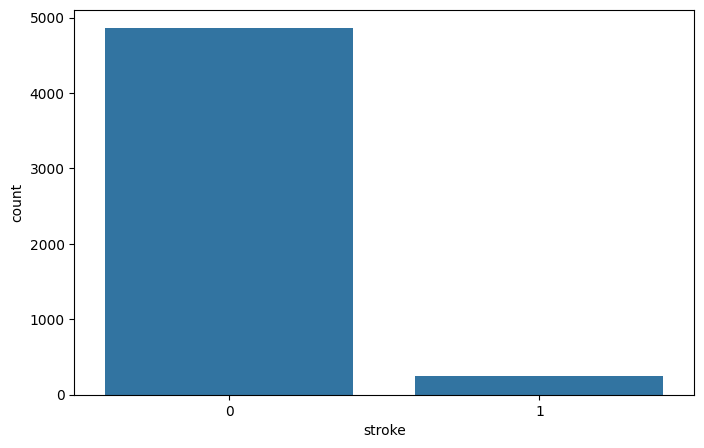

In [26]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='stroke'
)

plt.show()

- Stroke cases are very few.
- Dataset is highly imbalanced.
- Most patients did not suffer stroke.

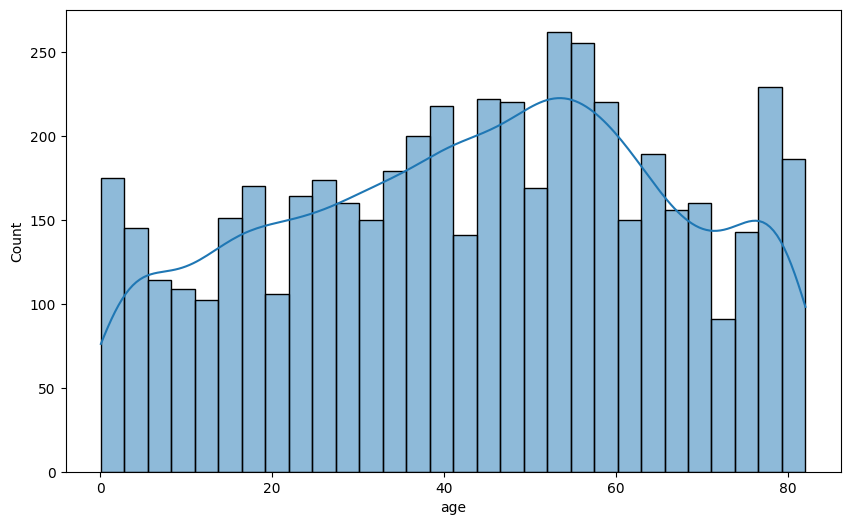

In [27]:
plt.figure(figsize=(10,6))

sns.histplot(
    df['age'],
    bins=30,
    kde=True
)

plt.show()

- Dataset covers all age groups.
- Higher concentration in adult and senior population.
- Stroke risk analysis will heavily depend on age

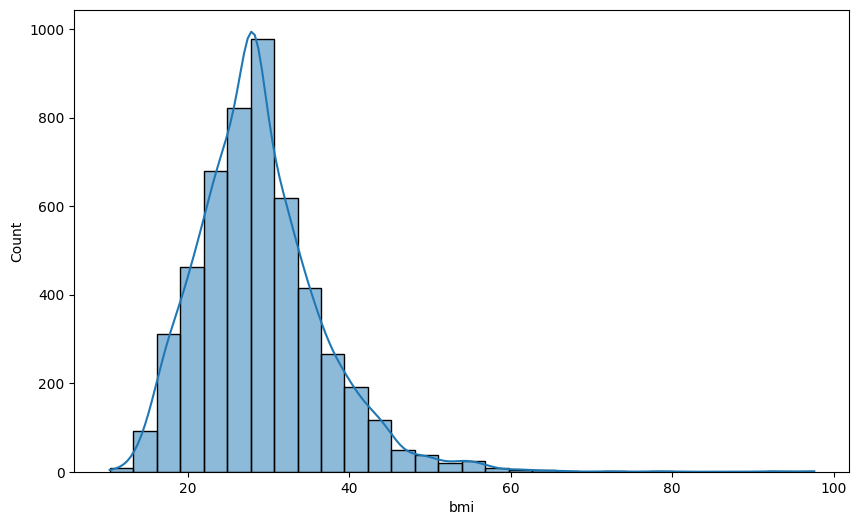

In [28]:
plt.figure(figsize=(10,6))

sns.histplot(
    df['bmi'],
    bins=30,
    kde=True
)

plt.show()

- Most individuals fall into normal-to-overweight range.
- Obesity cases are present.
- BMI may contribute to stroke risk.

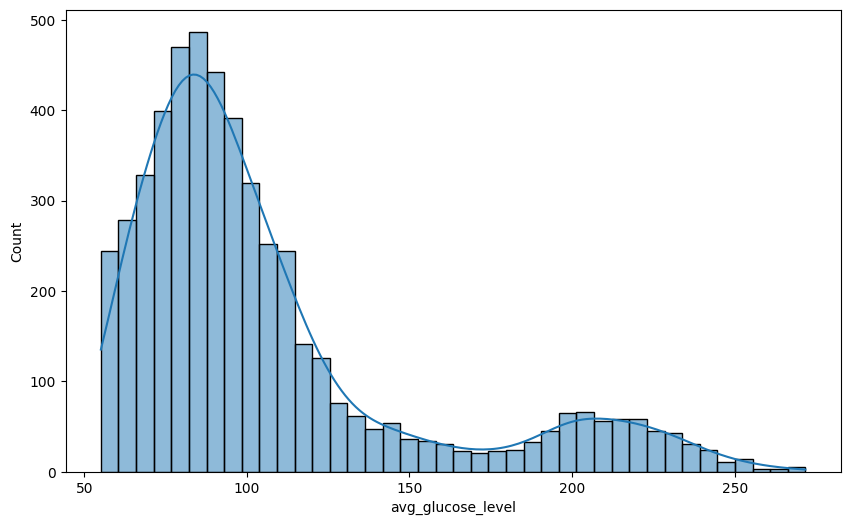

In [29]:
plt.figure(figsize=(10,6))

sns.histplot(
    df['avg_glucose_level'],
    bins=40,
    kde=True
)

plt.show()

- Glucose levels show right skewness.
- Some patients have extremely high glucose values.
- Diabetes-related risk may be present.

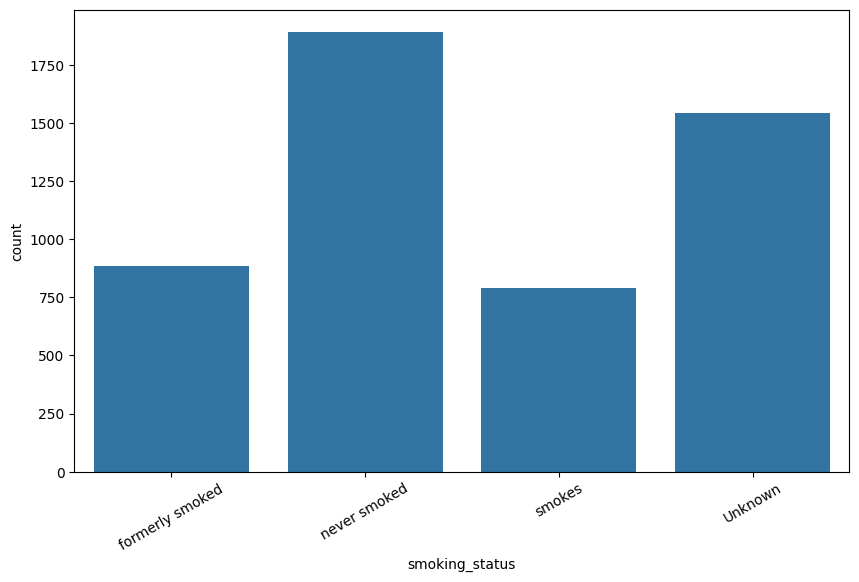

In [31]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x='smoking_status'
)

plt.xticks(rotation=30)

plt.show()

- Never-smokers dominate the dataset.
- and after that the domination is done by those people who did not disclose whether they smoke or not.
- Smoking-related risk can be explored further.

# BIVARIATE ANALYSIS
>**TARGET = STROKE**

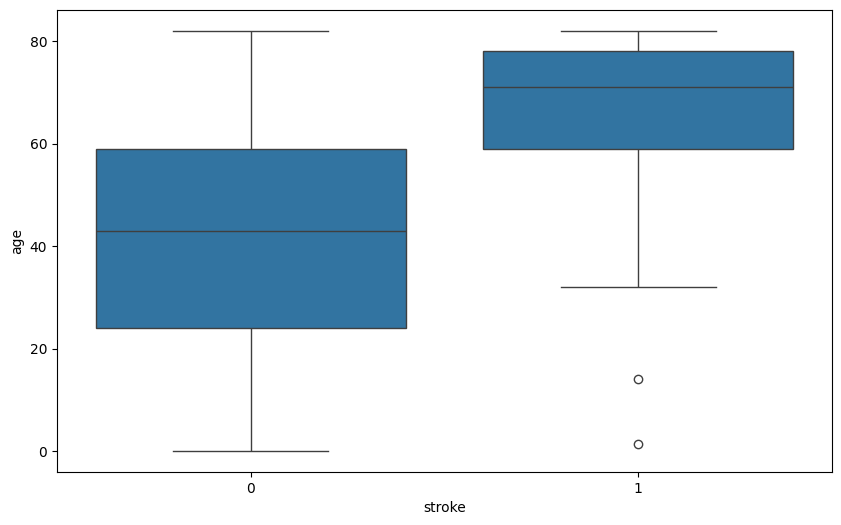

In [32]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,

    x='stroke',
    y='age'
)

plt.show()

- Stroke patients are significantly older.
- Stroke risk increases with age.
- The median age for stroke patients is 71, compared to just 43 for the non-stroke group. Age is a massive driving factor.

- **Under the age of 30, a stroke is incredibly rare.**

- The two dots at the bottom of the stroke plot prove that youth strokes do happen, but they are extreme, rare statistical outliers.

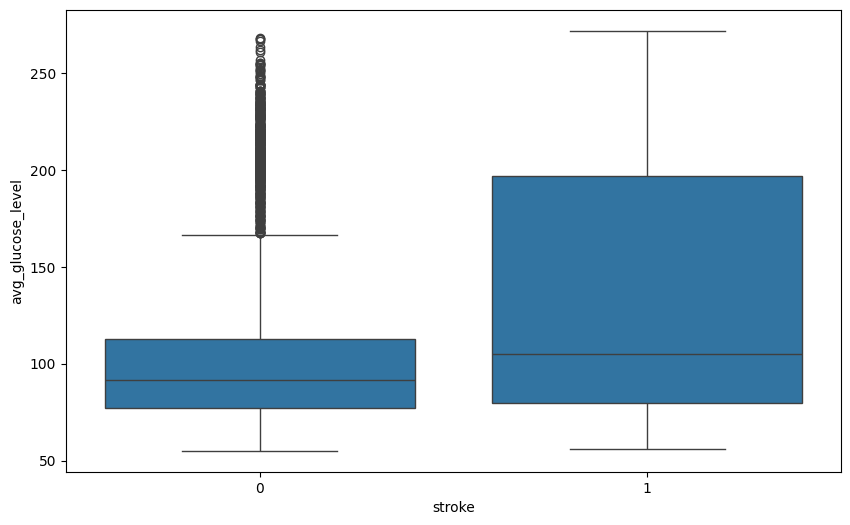

In [33]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,

    x='stroke',
    y='avg_glucose_level'
)

plt.show()

- For the non-stroke group , glucose levels are heavily concentrated below 115, representing a stable, healthy baseline.
- The High-Glucose Stretch: Look at how tall the stroke box is. The top 50% of stroke patients have significantly elevated glucose levels, stretching all the way from 105 up to 200+.
- The massive vertical tower of black dots above the non-stroke group shows that many people have high glucose without having a stroke yet—making it a major warning indicator rather than a definitive cause.
-  Interestingly, the medians (middle lines) are relatively close (around 92 vs 105). This means you can have a stroke with normal glucose, but high glucose drastically widens your overall risk window.

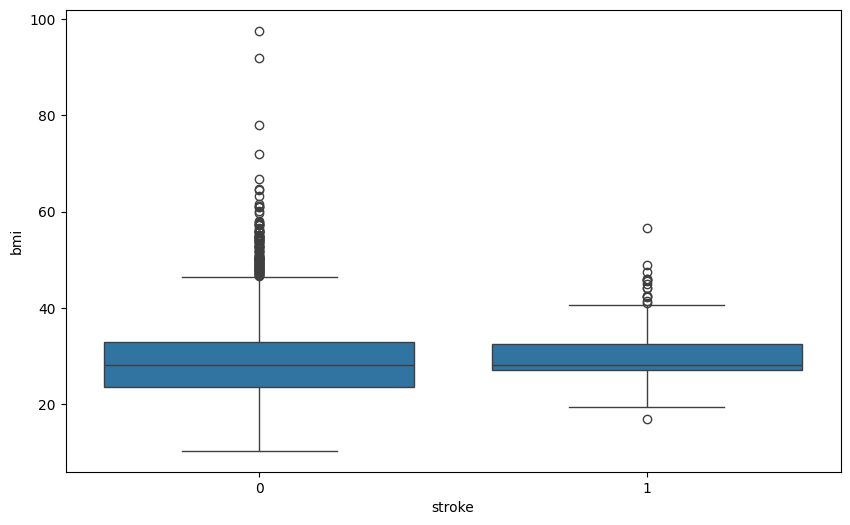

In [34]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,

    x='stroke',
    y='bmi'
)

plt.show()

- The non-stroke group has massive variance (spreading from 10 to 98 BMI), while the stroke group is highly restricted, showing that stroke risk heavily concentrates within a narrow physical profile.
-  Notice the lower whisker of the stroke group stops abruptly around a BMI of 20. This indicates a potential statistical floor—strokes are almost non-existent in underweight individuals in this dataset.
- The interquartile range (the blue box) for stroke patients is incredibly flat and dense between 27 and 32-24 BMI. This tells us that being slightly overweight to mildly obese is the core demographic zone where strokes occur.
- Because the medians are identical at 28, a simple linear model would fail to split these classes based on BMI. It proves that BMI requires interaction terms (like matching it with Age or Glucose) to have any real predictive value.

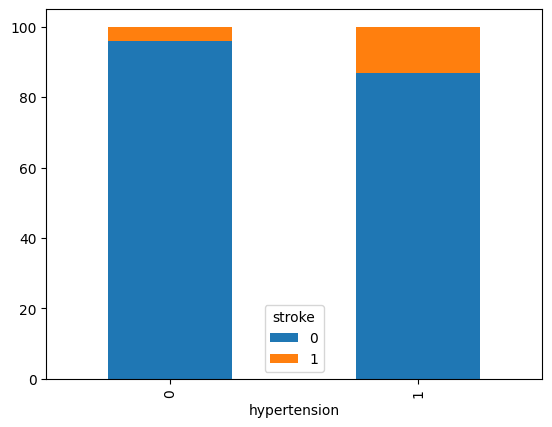

In [35]:
stroke_ht = pd.crosstab(
    df['hypertension'],
    df['stroke'],
    normalize='index'
)*100

stroke_ht.plot(
    kind='bar',
    stacked=True
)

plt.show()

- Stroke percentage is much higher among hypertensive patients.
- High blood pressure is a major risk factor.

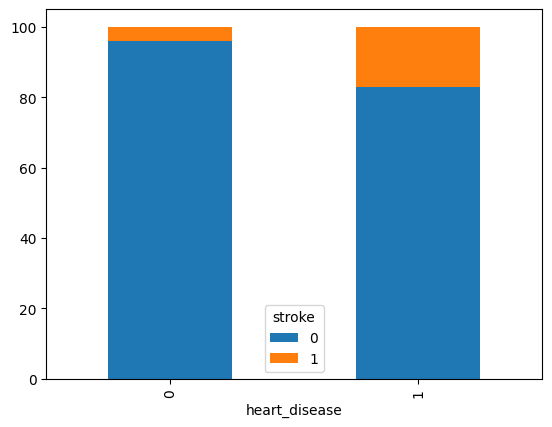

In [36]:
stroke_hd = pd.crosstab(
    df['heart_disease'],
    df['stroke'],
    normalize='index'
)*100

stroke_hd.plot(
    kind='bar',
    stacked=True
)

plt.show()

- Stroke occurrence is much higher among heart disease patients.
- Cardiovascular health strongly impacts stroke risk.

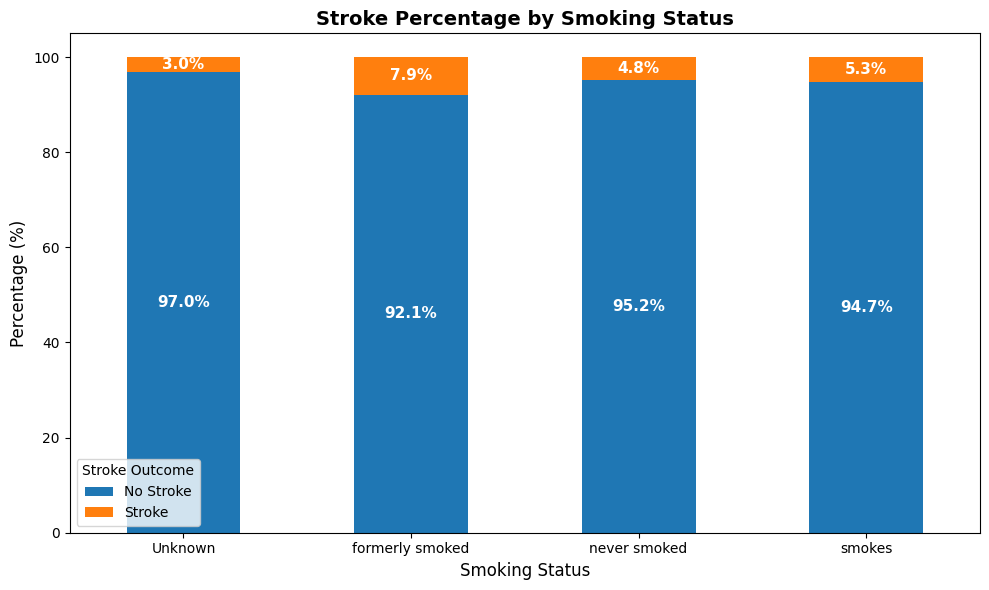

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

smoke = pd.crosstab(
    df['smoking_status'],
    df['stroke'],
    normalize='index'
) * 100

ax = smoke.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6)
)


for p in ax.patches:
    height = p.get_height() 
    
    if height > 0:
        x = p.get_x() + p.get_width() / 2.
        y = p.get_y() + height / 2.
        
      
        ax.text(x, y, f'{height:.1f}%', 
                ha='center', va='center',      
                color='white', fontweight='bold', fontsize=11)


plt.title('Stroke Percentage by Smoking Status', fontsize=14, fontweight='bold')
plt.xlabel('Smoking Status', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xticks(rotation=0) # Keeps the smoking status labels horizontal


plt.legend(title='Stroke Outcome', labels=['No Stroke', 'Stroke'])

plt.tight_layout() 
plt.show()

- Smokers generally show higher stroke rates.
- the percentage is higher seen in those person who used to smoke but quit now.
- Smoking appears to increase stroke vulnerability.

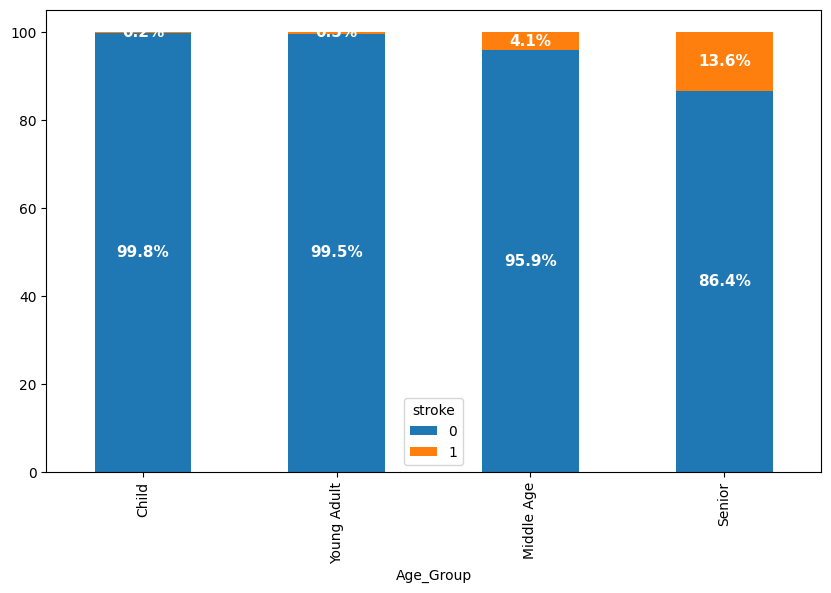

In [40]:
import pandas as pd
import matplotlib.pyplot as plt

age_stroke = pd.crosstab(
    df['Age_Group'],
    df['stroke'],
    normalize='index'
)*100

ax = age_stroke.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        x = p.get_x() + p.get_width() / 2.
        y = p.get_y() + height / 2.
        ax.text(x, y, f'{height:.1f}%', 
                ha='center', va='center', 
                color='white', fontweight='bold', fontsize=11)

plt.show()

- Senior citizens show the highest stroke percentage.
- Young populations show minimal stroke incidence.

# MULTIVARIATE ANALYSIS:

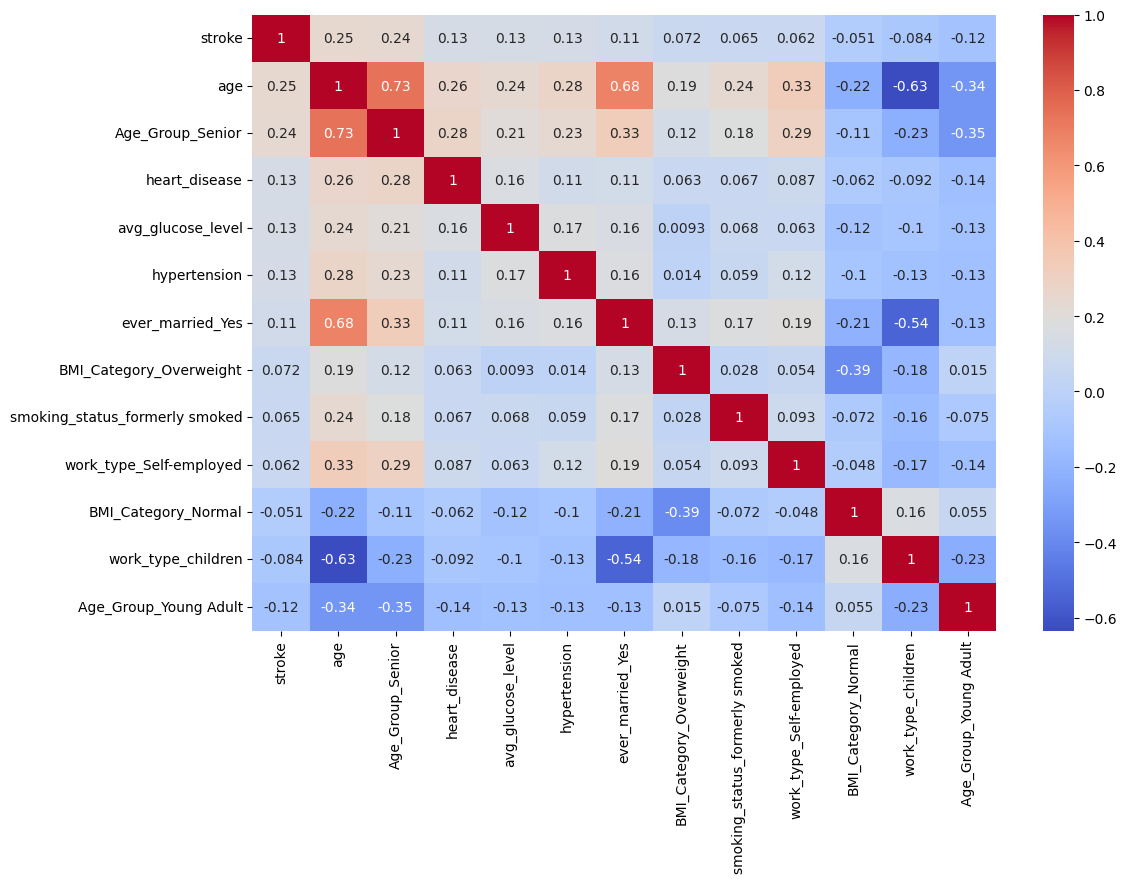

In [41]:
encoded_df = pd.get_dummies(
    df,
    drop_first=True
)

corr = encoded_df.corr()

stroke_corr = (
    corr['stroke']
    .sort_values(
        ascending=False
    )
)

important_cols = stroke_corr[
    abs(stroke_corr) > 0.05
].index

plt.figure(figsize=(12,8))

sns.heatmap(
    encoded_df[
        important_cols
    ].corr(),

    annot=True,

    cmap='coolwarm'
)

plt.show()

- The Top Predictor: age  and Age_Group_Senior  have the strongest positive correlation with stroke. Getting older is the single dominant driver in this dataset.
- The Secondary Layer: heart_disease , avg_glucose_level, and hypertension  share the exact same tie-level correlation with stroke. They represent the secondary, medical risk layer.

In [45]:
import plotly.express as px

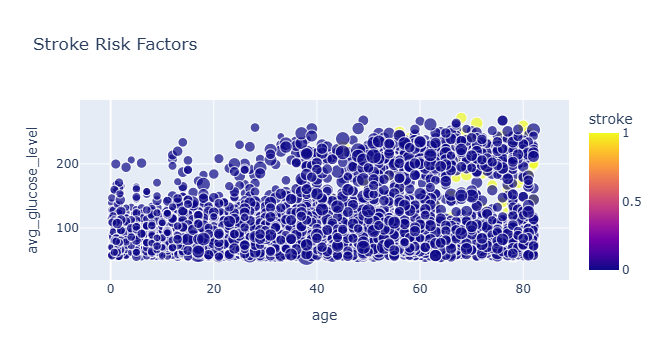

In [48]:
fig = px.scatter(

    df,

    x='age',
    y='avg_glucose_level',

    size='bmi',

    color='stroke',

    title='Stroke Risk Factors'
)

fig.show() 

- Stroke patients cluster at higher ages.
- High glucose further increases risk.
- Multiple risk factors combine together.

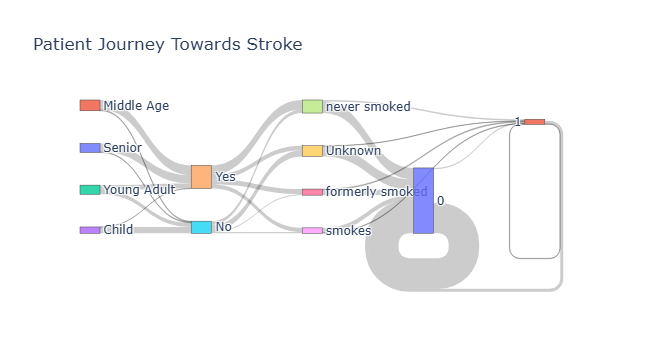

In [53]:
import plotly.graph_objects as go

cols = [
    'Age_Group',
    'ever_married',
    'smoking_status',
    'hypertension',
    'stroke'
]

labels = []

for col in cols:
    labels.extend(
        df[col].astype(str).unique()
    )

labels = list(dict.fromkeys(labels))

label_dict = {
    label:i
    for i,label in enumerate(labels)
}

source = []
target = []
value = []

for i in range(len(cols)-1):

    temp = (
        df.groupby(
            [cols[i], cols[i+1]]
        )
        .size()
        .reset_index(name='count')
    )

    for _,row in temp.iterrows():

        source.append(
            label_dict[
                str(row[cols[i]])
            ]
        )

        target.append(
            label_dict[
                str(row[cols[i+1]])
            ]
        )

        value.append(
            row['count']
        )

fig = go.Figure(
    go.Sankey(
        node=dict(
            label=labels
        ),

        link=dict(
            source=source,
            target=target,
            value=value
        )
    )
)

fig.update_layout(
    title='Patient Journey Towards Stroke'
)

fig.show()

-  A Senior who has been married and formerly smoked has the widest, most direct pipeline leading straight to a stroke.

- Shockingly, being a Senior/Middle-Aged person who never smoked still has a heavy flow leading to a stroke. This proves age and lifestyle history outweigh current good habits.

-  If you are a Child or Young Adult, your path completely bypasses the stroke risk entirely—showing youth acts as a total shield in this dataset.

- The data shows "Ever Married = Yes" is a massive gateway to strokes. However, this is just because older people are the ones who have been married; marriage doesn't cause strokes, growing older does.

# FINAL EDA REPORT
*Objective*

The goal was to identify factors associated with stroke occurrence and understand patient characteristics.

**Key Findings:**
1. **Age is the strongest predictor**
Stroke cases are concentrated among older individuals.
Senior citizens face significantly higher risk.
2. **Hypertension is a major risk factor**
Patients with high blood pressure show much higher stroke rates.
3. **Heart disease strongly increases risk**
Stroke is more common among cardiovascular patients.
4. **High glucose levels are associated with stroke**
Stroke patients generally exhibit elevated glucose values.
5. **Smoking contributes to risk**
Smokers show higher stroke percentages than non-smokers.
6. **Multiple risk factors work together**

The highest-risk patients generally exhibit:

older age
hypertension
heart disease
elevated glucose
obesity

rather than a single isolated factor.

> Final Conclusion

The analysis reveals that stroke is primarily driven by a combination of age, hypertension, heart disease, and glucose-related health conditions. Age emerged as the most influential factor, while cardiovascular conditions significantly amplify stroke risk. The findings suggest that preventive healthcare efforts should focus on older adults and patients with chronic cardiovascular and metabolic conditions.